# Integration by Parts: 3RScan & 3DSSG Pipeline

This notebook provides an end-to-end execution environment for adapting the dynamic scene graph model to the 3RScan and 3DSSG datasets. Running these cells in order will extract the data modalities, build the database, train the model, and evaluate the final SGCls and PredCls metrics.

In [1]:
import os
import sys
from pathlib import Path

# Ensure the mtp_pipeline module is in the path
sys.path.append(os.path.abspath('.'))

from mtp_pipeline.config import ProjectPaths, PipelineConfig

paths = ProjectPaths()
print(f"Data will be saved to: {paths.reference_root}")
print(f"Outputs will be saved to: {paths.output_root}")
text_output_dir = paths.reference_root / "3rscan_text_embeddings"
lidar_output_dir = paths.reference_root / "3rscan_lidar_tokens"
rgb_output_dir = paths.reference_root / "3rscan_rgb_temporal"





database_output = paths.output_root / "3rscan_database"

Data will be saved to: D:\MTP_Project\MTP_Pipeline_3RScan\pipeline_data
Outputs will be saved to: D:\MTP_Project\MTP_Pipeline_3RScan\pipeline_outputs


## 1. Extract Modalities
We need to extract the three core modalities: Text (CLIP), 3D Point Clouds (PointMAE), and 2D Video Frames (CLIP ViT).

In [10]:
# 1A. Text Embeddings
from mtp_pipeline.prepare_3rscan_text import prepare_3rscan_text_embeddings

objects_json = Path(r"D:\MTP_Project\3DSSG\objects.json")


prepare_3rscan_text_embeddings(
    objects_json=objects_json,
    output_dir=text_output_dir,
    model_name="openai/clip-vit-base-patch32",
    device="cuda"
)

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.post_layernorm.bias                               | UNEXPECTED |  | 
text_projection.weight                                         | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.l

In [11]:
# 1B. LiDAR Embeddings (PointMAE)
from mtp_pipeline.prepare_3rscan_lidar import prepare_3rscan_lidar_tokens

scan_dir = Path(r"D:\MTP_Project\3RScan")


prepare_3rscan_lidar_tokens(
    scan_dir=scan_dir,
    objects_json=objects_json,
    output_dir=lidar_output_dir,
    checkpoint=None,
    device="cuda"
)

Extracting LiDAR tokens for 3RScan objects: 100%|██████████████████████████████████| 1482/1482 [01:19<00:00, 18.69it/s]


In [12]:
# 1C. Continuous Video RGB Embeddings (Temporal)
from mtp_pipeline.prepare_3rscan_rgb import prepare_3rscan_rgb_tokens



prepare_3rscan_rgb_tokens(
    scan_dir=scan_dir,
    objects_json=objects_json,
    output_dir=rgb_output_dir,
    model_name="openai/clip-vit-base-patch32",
    device="cuda"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_projection.weight                                       | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_n

## 2. Build the Training Database
Merge the extracted modalities and link them with the 3DSSG ground truth relationship labels.

In [13]:
from mtp_pipeline.build_3rscan_database import build_3rscan_scene_database

relationships_json = Path(r"D:\MTP_Project\3DSSG\relationships.json")
database_output = paths.output_root / "3rscan_database"

build_3rscan_scene_database(
    rgb_dir=rgb_output_dir,
    lidar_dir=lidar_output_dir,
    text_dir=text_output_dir,
    relationships_json=relationships_json,
    output_dir=database_output
)

Building lazy-loading database: 100%|██████████████████████████████████████████████| 1135/1135 [04:14<00:00,  4.46it/s]


1135

## 3. Train the Integration by Parts Model
Train the model using the pooled temporal representations for static scene graph prediction.

In [2]:
import argparse
from mtp_pipeline.train import train

args = argparse.Namespace(
    reference_root=paths.reference_root,
    output_root=paths.output_root,
    database=database_output,
    epochs=50,
    max_scenes=None,
    max_frames=None,
    max_edges_per_frame=256,
    learning_rate=1e-4,
    lambda_temporal=1.0,
    lambda_temporal_part=0.5,
    lambda_node=1.0,
    lambda_edge=1.0,
    lambda_dynamic=0.5,
    grad_clip=1.0,
    device="cuda",
    shuffle=True,
    num_parts=7,
    ablation="none"
)

checkpoint_path = train(args)
print(f"Training finished. Checkpoint saved to: {checkpoint_path}")

Training on 908 scenes (Validation reserved: 227)
Computing Alpha class weights to balance rare 3DSSG relationships...


Epoch 1/50: 100%|█| 908/908 [09:46<00:00,  1.55it/s, total=15.1, representation=4.96, temporal=0.837, temporal_part=1.8
Epoch 2/50: 100%|█| 908/908 [10:03<00:00,  1.50it/s, total=12.1, representation=3.55, temporal=0.75, temporal_part=1.05
Epoch 3/50: 100%|█| 908/908 [10:06<00:00,  1.50it/s, total=11.3, representation=3.42, temporal=0.705, temporal_part=1.0
Epoch 4/50: 100%|█| 908/908 [10:07<00:00,  1.50it/s, total=10.7, representation=3.3, temporal=0.687, temporal_part=0.97
Epoch 5/50: 100%|█| 908/908 [10:14<00:00,  1.48it/s, total=10.2, representation=3.24, temporal=0.679, temporal_part=0.9
Epoch 6/50: 100%|█| 908/908 [10:06<00:00,  1.50it/s, total=9.8, representation=3.2, temporal=0.678, temporal_part=0.94,
Epoch 7/50: 100%|█| 908/908 [10:05<00:00,  1.50it/s, total=9.43, representation=3.17, temporal=0.674, temporal_part=0.9
Epoch 8/50: 100%|█| 908/908 [11:04<00:00,  1.37it/s, total=9.12, representation=3.14, temporal=0.675, temporal_part=0.9
Epoch 9/50: 100%|█| 908/908 [10:34<00:00

Saved checkpoint: D:\MTP_Project\MTP_Pipeline_3RScan\pipeline_outputs\checkpoints\integration_by_parts_3rscan_epoch_50.pt
Saved history: D:\MTP_Project\MTP_Pipeline_3RScan\pipeline_outputs\training_history_3rscan.json
Training finished. Checkpoint saved to: D:\MTP_Project\MTP_Pipeline_3RScan\pipeline_outputs\checkpoints\integration_by_parts_3rscan_epoch_50.pt


## 4. Plot Training History

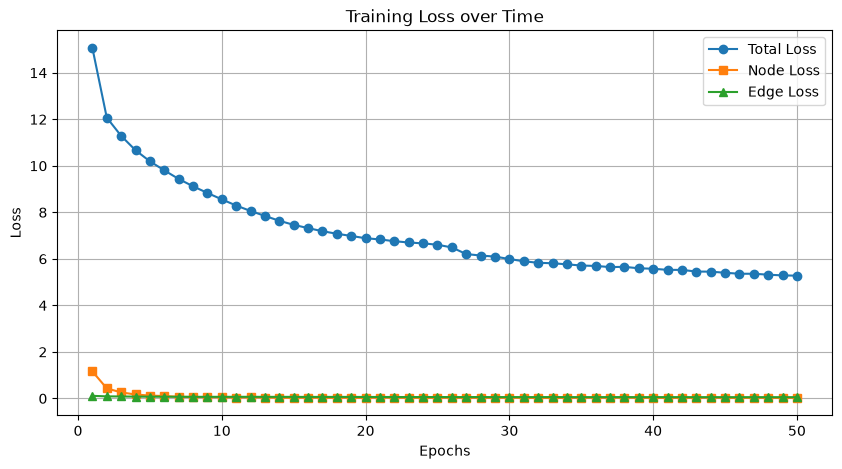

In [3]:
import json
import matplotlib.pyplot as plt

history_file = paths.output_root / "training_history_3rscan.json"
with open(history_file, 'r') as f:
    history = json.load(f)

epochs = [x['epoch'] for x in history]
total_loss = [x['total'] for x in history]
node_loss = [x['node'] for x in history]
edge_loss = [x['edge'] for x in history]

plt.figure(figsize=(10, 5))
plt.plot(epochs, total_loss, label='Total Loss', marker='o')
plt.plot(epochs, node_loss, label='Node Loss', marker='s')
plt.plot(epochs, edge_loss, label='Edge Loss', marker='^')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss over Time')
plt.legend()
plt.grid(True)
plt.show()

## 5. Evaluate SGCls and PredCls (Metrics)
Compare the model's metrics directly to the baseline Paper 2510.

In [4]:
from mtp_pipeline.evaluate_3dssg import evaluate_model

eval_args = argparse.Namespace(
    checkpoint=checkpoint_path,
    reference_root=paths.reference_root,
    output_root=paths.output_root,
    database=database_output,
    device="cuda"
)

evaluate_model(eval_args)

Loading database from D:\MTP_Project\MTP_Pipeline_3RScan\pipeline_outputs\3rscan_database...
Evaluating on 227 validation scenes...


C:\Users\SSR\AppData\Roaming\Python\Python311\site-packages\torch\nn\modules\transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(
Evaluating 3DSSG metrics: 100%|██████████████████████████████████████████████████████| 227/227 [02:42<00:00,  1.39it/s]


--- 3DSSG Evaluation Results ---
{
    "SGCls": {
        "R@20": 0.46253336573714976,
        "R@50": 0.6021723571490589,
        "R@100": 0.7210833384930656,
        "mR@20": 0.2311534110982779,
        "mR@50": 0.3382052306377825,
        "mR@100": 0.4037751578497433
    },
    "PredCls": {
        "R@20": 0.4635526199961158,
        "R@50": 0.6043281237760626,
        "R@100": 0.7228419277393558,
        "mR@20": 0.23230593130008065,
        "mR@50": 0.3413309227912361,
        "mR@100": 0.40535734807137547
    }
}
Saved evaluation results to D:\MTP_Project\MTP_Pipeline_3RScan\pipeline_outputs\checkpoints\evaluation_integration_by_parts_3rscan_epoch_50.json
